In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [2]:
model = joblib.load("../artifacts/linear_regression_model.pkl")

In [3]:
preprocessor = model.named_steps["preprocessor"]
linear_model = model.named_steps["model"]

In [4]:
feature_names = preprocessor.get_feature_names_out()
coefficients = linear_model.coef_

In [5]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

importance_df["absolute_coefficient"] = importance_df["coefficient"].abs()

importance_df.sort_values(
    by="absolute_coefficient",
    ascending=False
).head(30)

,feature,coefficient,absolute_coefficient
47,categorical__Neighborhood_StoneBr,0.145527,0.145527
31,categorical__Neighborhood_Crawfor,0.133648,0.133648
86,categorical__RoofMatl_ClyTile,-0.116271,0.116271
96,categorical__Exterior1st_BrkFace,0.108555,0.108555
41,categorical__Neighborhood_NridgHt,0.094330,0.094330
63,categorical__Condition2_PosN,-0.094287,0.094287
11,categorical__LandContour_Bnk,-0.082732,0.082732
199,categorical__Functional_Typ,0.082725,0.082725
35,categorical__Neighborhood_MeadowV,-0.081057,0.081057
194,categorical__Functional_Maj2,-0.077225,0.077225


In [6]:
top_features = importance_df.sort_values(
    by="absolute_coefficient",
    ascending=False
).head(30)

top_features

,feature,coefficient,absolute_coefficient
47,categorical__Neighborhood_StoneBr,0.145527,0.145527
31,categorical__Neighborhood_Crawfor,0.133648,0.133648
86,categorical__RoofMatl_ClyTile,-0.116271,0.116271
96,categorical__Exterior1st_BrkFace,0.108555,0.108555
41,categorical__Neighborhood_NridgHt,0.094330,0.094330
63,categorical__Condition2_PosN,-0.094287,0.094287
11,categorical__LandContour_Bnk,-0.082732,0.082732
199,categorical__Functional_Typ,0.082725,0.082725
35,categorical__Neighborhood_MeadowV,-0.081057,0.081057
194,categorical__Functional_Maj2,-0.077225,0.077225


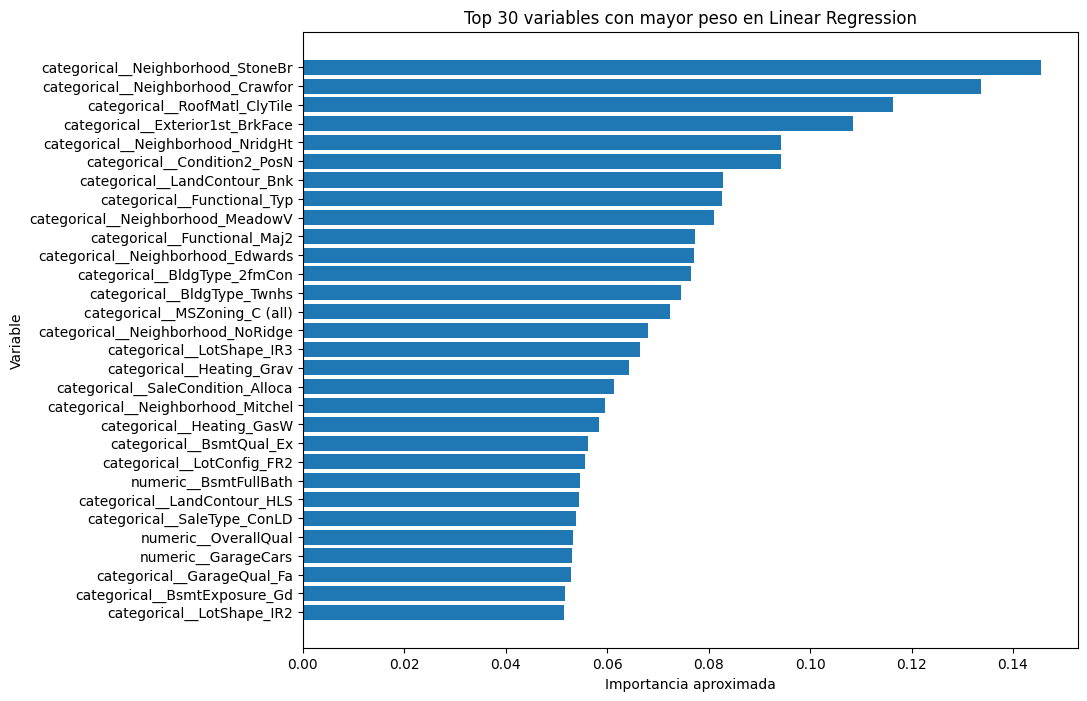

In [7]:
plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["absolute_coefficient"]
)

plt.xlabel("Importancia aproximada")
plt.ylabel("Variable")
plt.title("Top 30 variables con mayor peso en Linear Regression")

plt.gca().invert_yaxis()

plt.show()